
<div align="center">
  <h1>Tesla Stock Price Prediction</h1>
</div>

In [1]:
import pandas as p
df = p.read_csv('tsla_2014_2023.csv')


In [ ]:
# Taking head count 
df.head()

In [ ]:
# checking if there are null values 
df.isnull().sum()

In [21]:
# checking shape 
df.shape 

(2516, 19)

In [ ]:
df.info()

In [ ]:
#the index from the dataset and set the “date” column as the index.
df['date'] = p.to_datetime(df['date'])
df.set_index('date', inplace=True)
df.head()

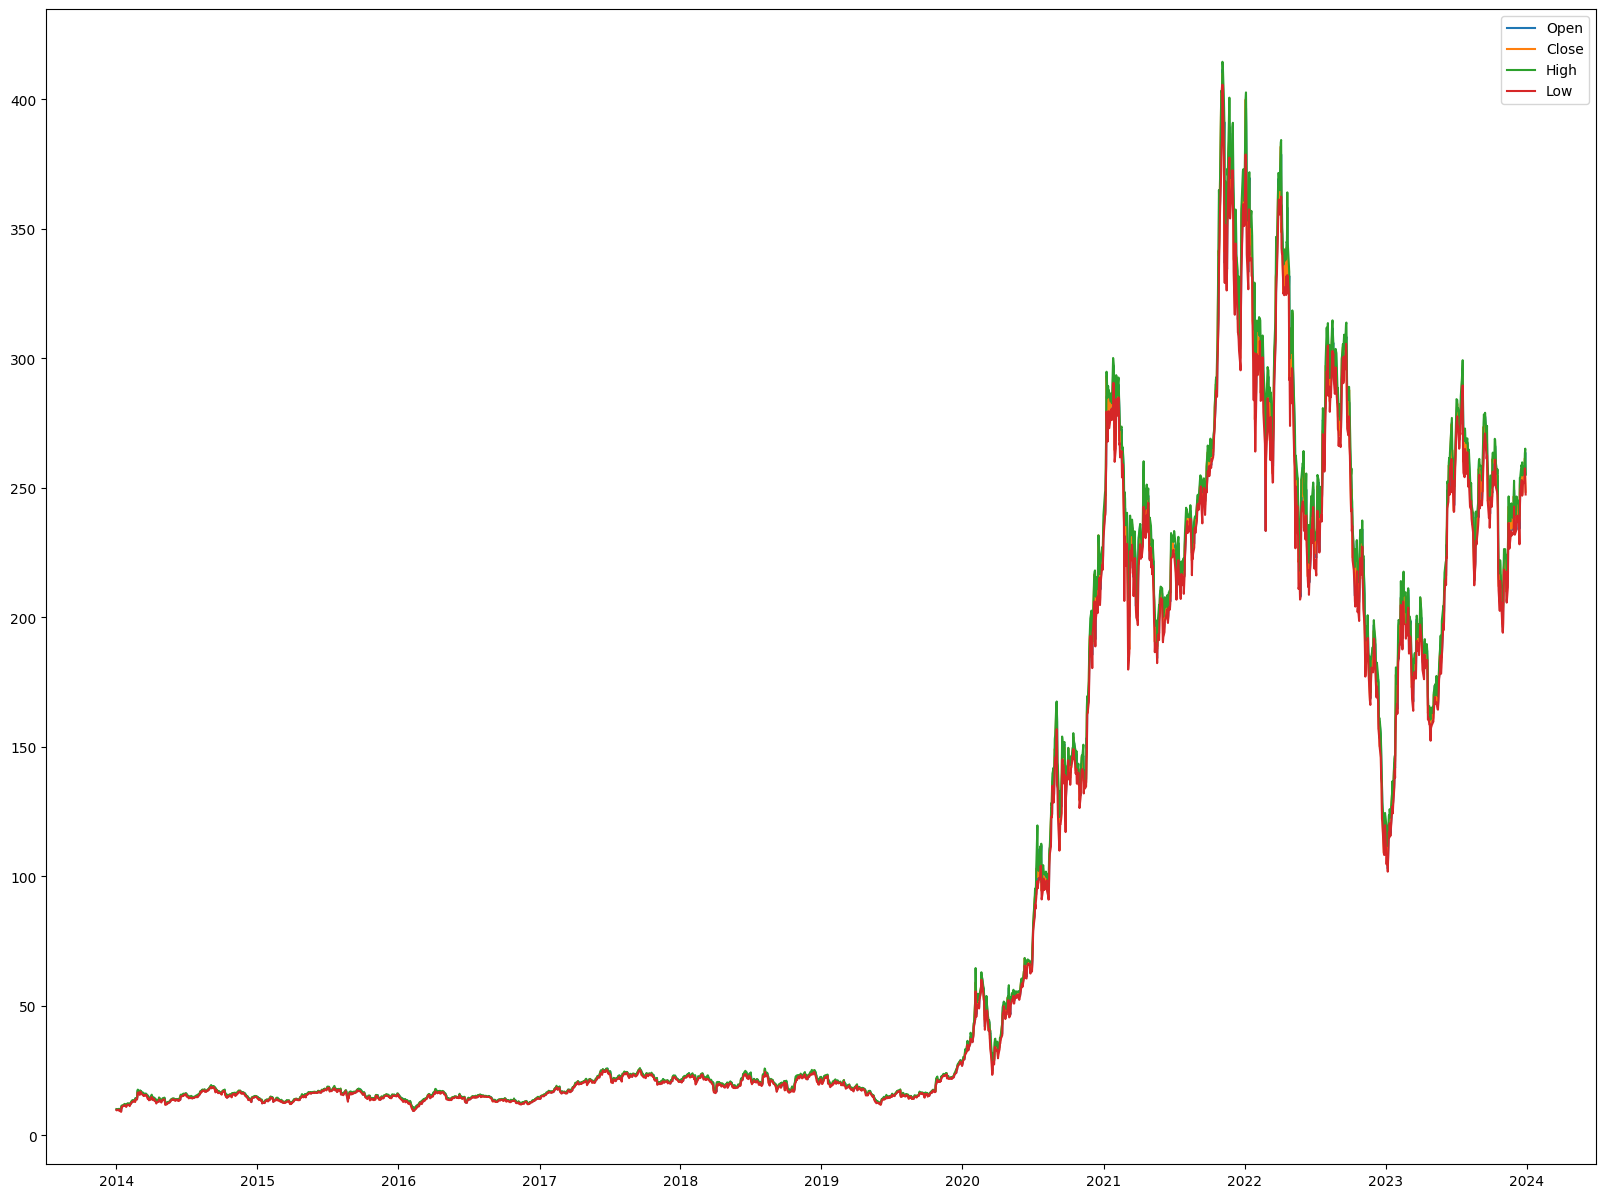

In [9]:
import matplotlib.pyplot as plt
plt.figure(figsize=(20, 15))
plt.plot(df.index, df['open'], label='Open')
plt.plot(df.index, df['close'], label='Close')
plt.plot(df.index, df['high'], label='High')
plt.plot(df.index, df['low'], label='Low')
plt.legend()

<Axes: >

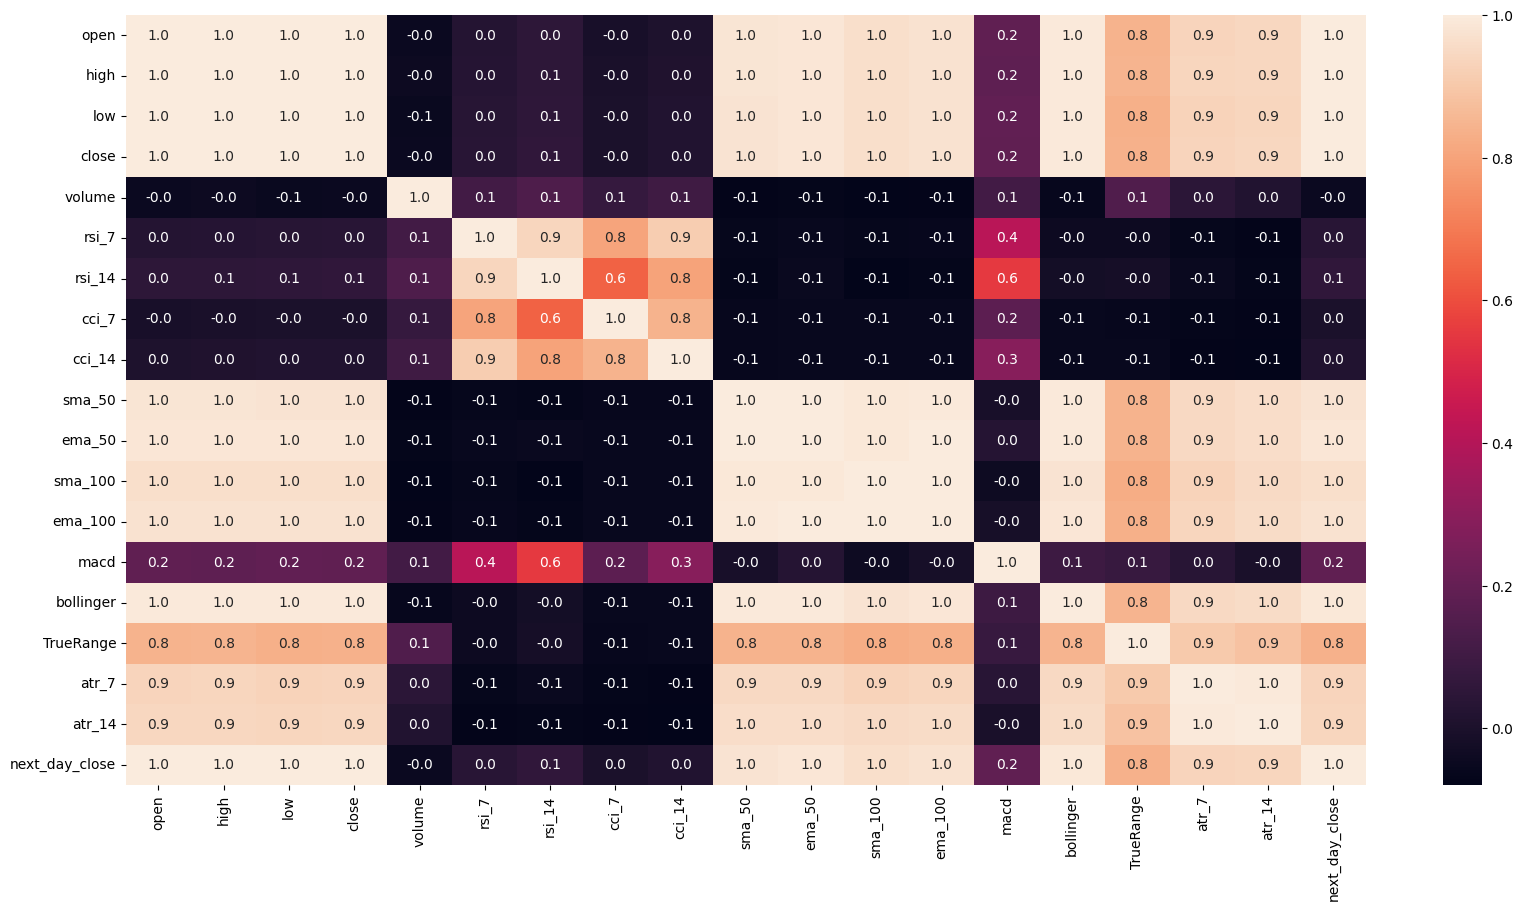

In [10]:
df_corr = df.corr()
import seaborn as sns
plt.figure(figsize=(20, 10))
sns.heatmap(df_corr, annot=True, fmt='.1f')

In [11]:
y = df['next_day_close']
X = df.drop(columns='next_day_close')

In [12]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
random_state=777)

In [ ]:
# split these into training and testing sets and import StandardScaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)
X_train_scaled.shape, X_test_scaled.shape # ((2012, 18), (504, 18))

((2012, 18), (504, 18))

In [ ]:
# LinearRegression
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

In [15]:
lr.fit(X_train, y_train)
lr_prediction = lr.predict(X_test)
from sklearn.metrics import mean_absolute_error
lr_mae = mean_absolute_error(y_test, lr_prediction)
lr_mae # 2.3867493377843387

2.386749337869555

In [ ]:
#Decision Tree Regressor
from sklearn.tree import DecisionTreeRegressor
dtr = DecisionTreeRegressor()
dtr.fit(X_train, y_train)
dtr_prediction = dtr.predict(X_test)
dtr_mae = mean_absolute_error(y_test, dtr_prediction)
dtr_mae #3.588850648809524

3.7410663095238097

In [ ]:
#RandomForestRegressor
from sklearn.ensemble import RandomForestRegressor
rfr = RandomForestRegressor()
rfr.fit(X_train, y_train)
rfr_prediction = rfr.predict(X_test)
rfr_mae = mean_absolute_error(y_test, rfr_prediction)
rfr_mae #2.7267115297023783

2.6628877153769848

In [ ]:
#Support Vector Regressor
from sklearn.svm import SVR
svr = SVR()
svr.fit(X_train, y_train)
svr_prediction = svr.predict(X_test)
svr_mae = mean_absolute_error(y_test, svr_prediction)
svr_mae #74.6380006751906

74.63800067519058